In [20]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from glob import glob
from scipy.stats import pearsonr
from matplotlib.colors import LogNorm, Normalize

# =========================
# Configuration
# =========================

metrics = [
    "avg norm rank of source_mean",
    "accuracy_mean",
    "source in top 20_mean",
]

metadata_metrics = [
    "average_degree", 
    "density", 
    "number_of_nodes", 
    "number_of_perturbed_genes_in_pathway", 
    "number_of_edges", 
    "number_of_sig_info_in_pathway"
]

kegg_file = "kegg_nodes_metrics.json"
metadata_metric_for_nodecolor = "number_of_nodes"

# Define ranges for filtering (optional)
# Format: {"metric_name": (min_value, max_value)}
# Set to None or empty dict to disable filtering
metadata_ranges = {
    #"number_of_perturbed_genes_in_pathway": (60, 70),  # Example: only show pathways with 60-70 nodes
    #"average_degree": (1.0, 3.0),  # Example: uncomment to filter by degree
    #"number_of_sig_info_in_pathway": (4500, 20000),
}

# =========================
# Helpers
# =========================

def normalize_name(name: str) -> str:
    base = name.lower()
    base = base.replace("_", " ")
    base = base.replace("-", " ")
    base = base.split("(")[0]
    base = base.replace("pathway", "")
    base = base.strip()
    return "_".join(base.split())


def aggregate_mean_std(stats):
    """
    stats: list of tuples (n, mean, std)
    returns: (mean, std)
    """
    total_n = sum(n for n, _, _ in stats)
    if total_n == 0:
        return np.nan, np.nan

    mean = sum(n * m for n, m, _ in stats) / total_n
    var = (
        sum(n * (s**2 + m**2) for n, m, s in stats) / total_n
        - mean**2
    )
    return mean, np.sqrt(var)

# =========================
# Load KEGG metadata
# =========================

if not os.path.exists(kegg_file):
    raise FileNotFoundError(f"Required file '{kegg_file}' not found.")

with open(kegg_file, "r") as f:
    kegg_metadata = json.load(f)

kegg_metric = {}
for raw_name, metadata in kegg_metadata.items():
    print(f"Processing KEGG entry: {raw_name}")
    print(f"Metadata available: {metadata.keys()}")
    if metadata_metric_for_nodecolor not in metadata:
        continue
    kegg_metric[normalize_name(raw_name)] = metadata[metadata_metric_for_nodecolor]

# Load all metadata metrics for filtering
kegg_all_metrics = {}
for raw_name, metadata in kegg_metadata.items():
    normalized = normalize_name(raw_name)
    kegg_all_metrics[normalized] = metadata

# =========================
# Prepare data container
# =========================

data = {
    metric: {
        "pdgrapher": [],
        "pdgraphernognn": [],
        "pdgrapher_std": [],
        "pdgraphernognn_std": [],
        "experiment": [],
        "metadata_metric": [],
    }
    for metric in metrics
}

# =========================
# Load experiment results
# =========================

experiment_dirs = [
    d for d in os.listdir(".")
    if os.path.isdir(d)
]

if not experiment_dirs:
    raise FileNotFoundError("No experiment directories found.")

for exp_dir in experiment_dirs:
    json_files = glob(os.path.join(exp_dir, "*.json"))
    if not json_files:
        continue

    accum = {
        metric: {
            "pdgrapher": [],
            "pdgraphernognn": [],
        }
        for metric in metrics
    }

    experiment_name = None
    metadata_value = None
    should_include = True

    # print(f"Found {len(json_files)} JSON files in directory '{exp_dir}'.")
    # print(f"Json Files in '{exp_dir}': {json_files}")

    for file in json_files:
        with open(file, "r") as f:
            content = json.load(f)

        if experiment_name is None:
            experiment_name = content.get("experiment")
            if experiment_name is None:
                raise ValueError(f"'experiment' missing in {file}")
            
            print(f"Processing experiment: {experiment_name}")

            normalized_experiment = normalize_name(experiment_name)
            for key in kegg_metric:
                if normalized_experiment in key:
                    normalized_experiment = key
                    break
            # try capitalized version as well
            for key in kegg_metric:
                if normalized_experiment.capitalize() in key:
                    normalized_experiment = key
                    break

            if normalized_experiment not in kegg_metric:
                raise ValueError(
                    f"Experiment '{experiment_name}' not found in KEGG metadata."
                )

            metadata_value = kegg_metric[normalized_experiment]
            
            # Check if this experiment passes all range filters
            if metadata_ranges:
                for filter_metric, (min_val, max_val) in metadata_ranges.items():
                    if filter_metric in kegg_all_metrics[normalized_experiment]:
                        exp_value = kegg_all_metrics[normalized_experiment][filter_metric]
                        if not (min_val <= exp_value <= max_val):
                            should_include = False
                            print(f"Filtering out '{experiment_name}': {filter_metric}={exp_value} not in range [{min_val}, {max_val}]")
                            break

        if not should_include:
            break

        k_folds = content.get("k_folds")
        if k_folds is None:
            raise ValueError(f"'k_folds' missing in {file}")

        results = content.get("results")
        pdg = results.get("pdgrapher")
        pdg_ng = results.get("pdgraphernognn")

        for metric in metrics:
            std_metric = metric.replace("_mean", "_std")

            accum[metric]["pdgrapher"].append(
                (k_folds, pdg[metric], pdg[std_metric])
            )
            accum[metric]["pdgraphernognn"].append(
                (k_folds, pdg_ng[metric], pdg_ng[std_metric])
            )

    # Only add data if this experiment passed the filters
    if should_include:
        for metric in metrics:
            pdg_mean, pdg_std = aggregate_mean_std(accum[metric]["pdgrapher"])
            ng_mean, ng_std = aggregate_mean_std(accum[metric]["pdgraphernognn"])

            data[metric]["pdgrapher"].append(pdg_mean)
            data[metric]["pdgraphernognn"].append(ng_mean)
            data[metric]["pdgrapher_std"].append(pdg_std)
            data[metric]["pdgraphernognn_std"].append(ng_std)
            data[metric]["experiment"].append(experiment_name)
            data[metric]["metadata_metric"].append(metadata_value)

# =========================
# Dynamic color normalization
# =========================

all_meta_values = np.array(
    [v for metric in metrics for v in data[metric]["metadata_metric"]],
    dtype=float,
)

if len(all_meta_values) == 0:
    raise ValueError("No data points remain after filtering. Please adjust your metadata_ranges.")

vmin = np.min(all_meta_values)
vmax = np.max(all_meta_values)

if vmin > 0 and vmax / vmin >= 100:
    color_norm = LogNorm(vmin=vmin, vmax=vmax)
    colorbar_label = f"{metadata_metric_for_nodecolor} (log scale)"
else:
    color_norm = Normalize(vmin=vmin, vmax=vmax)
    colorbar_label = metadata_metric_for_nodecolor

# =========================
# Plot
# =========================

num_metrics = len(metrics)
fig, axs = plt.subplots(1, num_metrics, figsize=(6 * num_metrics, 6))
if num_metrics == 1:
    axs = [axs]

mappable = None

for i, metric in enumerate(metrics):
    ax = axs[i]

    x = data[metric]["pdgrapher"]
    y = data[metric]["pdgraphernognn"]
    xerr = data[metric]["pdgrapher_std"]
    yerr = data[metric]["pdgraphernognn_std"]
    node_colors = data[metric]["metadata_metric"]
    experiments = data[metric]["experiment"]

    scatter = ax.scatter(
        x,
        y,
        c=node_colors,
        cmap="viridis",
        norm=color_norm,
        s=90,
        edgecolors="black",
        linewidths=0.5,
        zorder=2,
    )
    mappable = scatter

    ax.errorbar(
        x,
        y,
        xerr=xerr,
        yerr=yerr,
        fmt="none",
        ecolor="black",
        elinewidth=1,
        alpha=0.6,
        capsize=3,
        zorder=1,
    )

    for j, experiment in enumerate(experiments):
        if "combined" in experiment.lower():
            ax.annotate(
                experiment,
                (x[j], y[j]),
                textcoords="offset points",
                xytext=(0, 8),
                ha="center",
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7),
            )

    if len(x) > 1:
        corr, _ = pearsonr(x, y)
        ax.set_title(f"{metric}\nPearson r = {corr:.2f}")
    else:
        ax.set_title(metric)

    ax.set_xlabel("pdgrapher")
    ax.set_ylabel("pdgraphernognn")

    diag_min = min(min(x), min(y))
    diag_max = max(max(x), max(y))
    ax.plot([diag_min, diag_max], [diag_min, diag_max], "r--", alpha=0.7)

# Add filter info to title
filter_info = ""
if metadata_ranges:
    filter_parts = [f"{k}: [{v[0]}, {v[1]}]" for k, v in metadata_ranges.items()]
    filter_info = f" (Filtered: {', '.join(filter_parts)})"
fig.suptitle(f"Comparison across experiments{filter_info}", fontsize=12, y=0.98)

plt.tight_layout(rect=[0, 0, 0.9, 0.96])


cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(mappable, cax=cax)
cbar.set_label(colorbar_label)

output_filename = "comparison_scatter_plots"
if metadata_ranges:
    range_suffix = "_".join([f"{k}_{v[0]}-{v[1]}" for k, v in metadata_ranges.items()])
    output_filename += f"_filtered_{range_suffix}"
output_filename += ".png"

plt.savefig(output_filename)
print(f"Saved plot to {output_filename}")
print(f"Number of experiments plotted: {len(data[metrics[0]]['experiment'])}")
plt.close(fig)

Processing KEGG entry: Acute Myeloid Leukemia (hsa05221)
Metadata available: dict_keys(['number_of_nodes', 'number_of_edges', 'average_degree', 'density', 'number_of_perturbed_genes_in_pathway', 'number_of_sig_info_in_pathway'])
Processing KEGG entry: Adherens Junction (hsa04520)
Metadata available: dict_keys(['number_of_nodes', 'number_of_edges', 'average_degree', 'density', 'number_of_perturbed_genes_in_pathway', 'number_of_sig_info_in_pathway'])
Processing KEGG entry: Adipocytokine Signaling (hsa04920)
Metadata available: dict_keys(['number_of_nodes', 'number_of_edges', 'average_degree', 'density', 'number_of_perturbed_genes_in_pathway', 'number_of_sig_info_in_pathway'])
Processing KEGG entry: Adrenergic Signaling In Cardiomyocytes (hsa04261)
Metadata available: dict_keys(['number_of_nodes', 'number_of_edges', 'average_degree', 'density', 'number_of_perturbed_genes_in_pathway', 'number_of_sig_info_in_pathway'])
Processing KEGG entry: African Trypanosomiasis (hsa05143)
Metadata avail

Row 1/6: Metadata metric 'average_degree' with vmin=1.0816326530612246, vmax=16.554054054054053
Row 2/6: Metadata metric 'density' with vmin=0.0027938072738660966, vmax=0.22370343316289262
Row 3/6: Metadata metric 'number_of_nodes' with vmin=38.0, vmax=2710.0
Row 4/6: Metadata metric 'number_of_perturbed_genes_in_pathway' with vmin=14.0, vmax=1439.0
Row 5/6: Metadata metric 'number_of_edges' with vmin=53.0, vmax=20518.0
Row 6/6: Metadata metric 'number_of_sig_info_in_pathway' with vmin=664.0, vmax=77771.0


/tmp/ipykernel_2170688/2034761950.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 0.97])


0 0 avg norm rank of source_mean
Pearson r = 0.68
0 1 accuracy_mean
Pearson r = 0.69
0 2 source in top 20_mean
Pearson r = 0.95
1 0 avg norm rank of source_mean
Pearson r = 0.68
1 1 accuracy_mean
Pearson r = 0.69
1 2 source in top 20_mean
Pearson r = 0.95
2 0 avg norm rank of source_mean
Pearson r = 0.68
2 1 accuracy_mean
Pearson r = 0.69
2 2 source in top 20_mean
Pearson r = 0.95
3 0 avg norm rank of source_mean
Pearson r = 0.68
3 1 accuracy_mean
Pearson r = 0.69
3 2 source in top 20_mean
Pearson r = 0.95
4 0 avg norm rank of source_mean
Pearson r = 0.68
4 1 accuracy_mean
Pearson r = 0.69
4 2 source in top 20_mean
Pearson r = 0.95
5 0 avg norm rank of source_mean
Pearson r = 0.68
5 1 accuracy_mean
Pearson r = 0.69
5 2 source in top 20_mean
Pearson r = 0.95
Saved plot to comparison_scatter_plots_grid.png


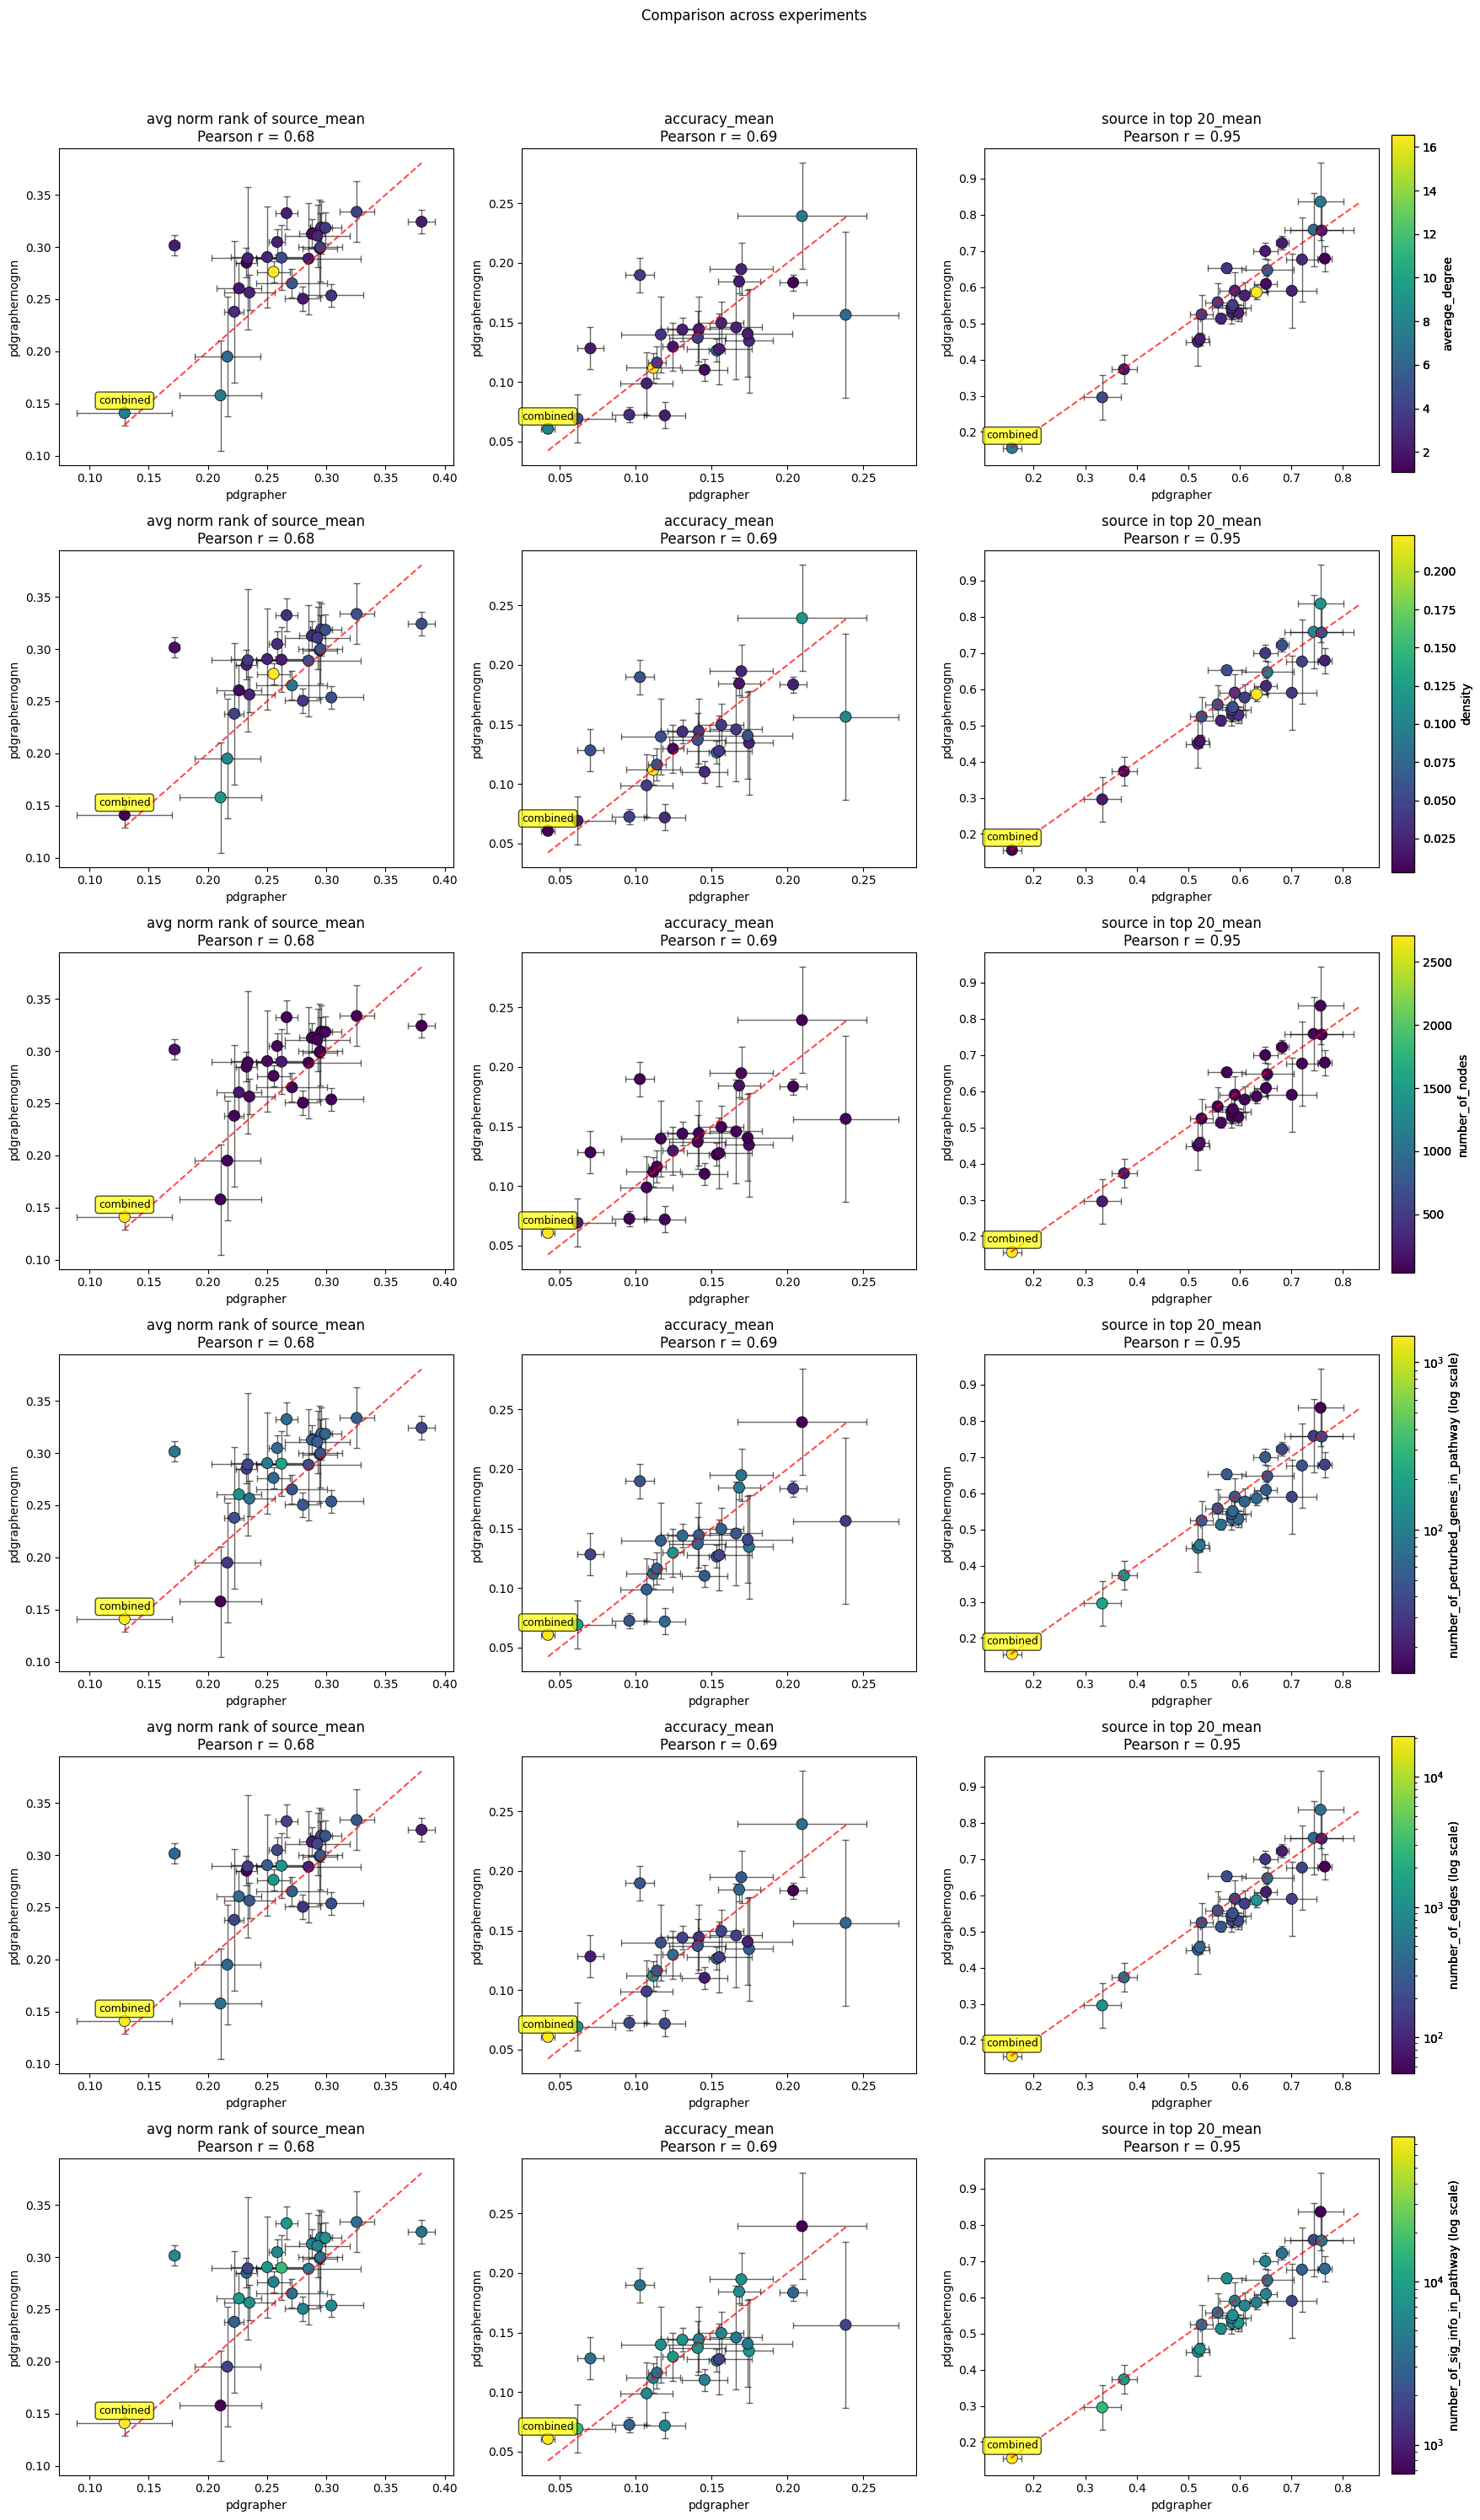

In [26]:
# =========================
# Plot grid: rows = metadata metrics, columns = metrics
# =========================

num_meta = len(metadata_metrics)
num_perf = len(metrics)

fig, axs = plt.subplots(num_meta, num_perf, figsize=(6 * num_perf, 5 * num_meta))

if num_meta == 1:
    axs = np.array([axs])
if num_perf == 1:
    axs = axs.reshape(num_meta, 1)

for row_idx, meta_metric in enumerate(metadata_metrics):
    ax = axs[num_meta - 1 - row_idx, col_idx]

    # Collect all values for this metadata metric for normalizationc
    meta_values = []
    for perf_metric in metrics:
        normalized_exps = [
            normalize_name(exp) for exp in data[perf_metric]["experiment"]
        ]
        for exp_name in normalized_exps:
            if exp_name in kegg_all_metrics:
                meta_values.append(kegg_all_metrics[exp_name].get(meta_metric, np.nan))

    meta_values = np.array(meta_values, dtype=float)
    meta_values = meta_values[~np.isnan(meta_values)]

    if len(meta_values) == 0:
        print(f"No data for metadata metric '{meta_metric}', skipping row.")
        continue

    vmin, vmax = np.min(meta_values), np.max(meta_values)

    print(f"Row {row_idx+1}/{num_meta}: Metadata metric '{meta_metric}' with vmin={vmin}, vmax={vmax}")

    if vmin > 0 and vmax / vmin >= 100:
        norm = LogNorm(vmin=vmin, vmax=vmax)
        cbar_label = f"{meta_metric} (log scale)"
    else:
        norm = Normalize(vmin=vmin, vmax=vmax)
        cbar_label = meta_metric

    mappable = None

    for col_idx, perf_metric in enumerate(metrics):
        ax = axs[row_idx, col_idx]

        x = data[perf_metric]["pdgrapher"]
        y = data[perf_metric]["pdgraphernognn"]
        xerr = data[perf_metric]["pdgrapher_std"]
        yerr = data[perf_metric]["pdgraphernognn_std"]
        node_colors = meta_values
        exps = data[perf_metric]["experiment"]

        # Get metadata values for current metric
        avg_meta = []
        for exp in exps:
            avg_meta.append(
                kegg_all_metrics.get(normalize_name(exp), {}).get(meta_metric, 0.0)
            )

        scatter = ax.scatter(
            x,
            y,
            c=avg_meta,
            cmap="viridis",
            norm=norm,
            s=90,
            edgecolors="black",
            linewidths=0.5,
            zorder=2,
        )

        mappable = scatter

        ax.errorbar(
            x,
            y,
            xerr=xerr,
            yerr=yerr,
            fmt="none",
            ecolor="black",
            elinewidth=1,
            alpha=0.6,
            capsize=3,
            zorder=1,
        )


        for j, experiment in enumerate(exps):
            if "combined" in experiment.lower():
                ax.annotate(
                    experiment,
                    (x[j], y[j]),
                    textcoords="offset points",
                    xytext=(0, 8),
                    ha="center",
                    fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7),
                )
            # else:
            #     ax.annotate(
            #         experiment,
            #         (x[j], y[j]),
            #         textcoords="offset points",
            #         xytext=(0, 8),
            #         ha="center",
            #         fontsize=9,
            #     )

        if len(x) > 1:
            corr, _ = pearsonr(x, y)
            ax.set_title(f"{perf_metric}\nPearson r = {corr:.2f}")
        else:
            ax.set_title(perf_metric)

        ax.set_xlabel("pdgrapher")
        ax.set_ylabel("pdgraphernognn")

        diag_min = min(min(x), min(y))
        diag_max = max(max(x), max(y))
        ax.plot([diag_min, diag_max], [diag_min, diag_max], "r--", alpha=0.7)

        cax = fig.add_axes([
            0.92,
            (num_meta - 1 - row_idx) * (0.95 / num_meta) + 0.02,
            0.015,
            0.8 / num_meta
        ])

        cbar = fig.colorbar(mappable, cax=cax)
        cbar.set_label(cbar_label)

# Add filter info to title
filter_info = ""
if metadata_ranges:
    filter_parts = [f"{k}: [{v[0]}, {v[1]}]" for k, v in metadata_ranges.items()]
    filter_info = f" (Filtered: {', '.join(filter_parts)})"
fig.suptitle(f"Comparison across experiments{filter_info}", fontsize=12, y=0.995)

plt.tight_layout(rect=[0, 0, 0.92, 0.97])


for exp in data[metrics[0]]["experiment"]:
    key = normalize_name(exp)
    if key not in kegg_all_metrics:
        print("MISSING:", exp, "->", key)

for r in range(num_meta):
    for c in range(num_perf):
        print(r, c, axs[r,c].get_title())

output_filename = "comparison_scatter_plots_grid.png"
plt.savefig(output_filename)
print(f"Saved plot to {output_filename}")
plt.close(fig)
fig


/tmp/ipykernel_2170688/1016590563.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 0.97])


Saved plot to comparison_ratio_scatter_grid.png


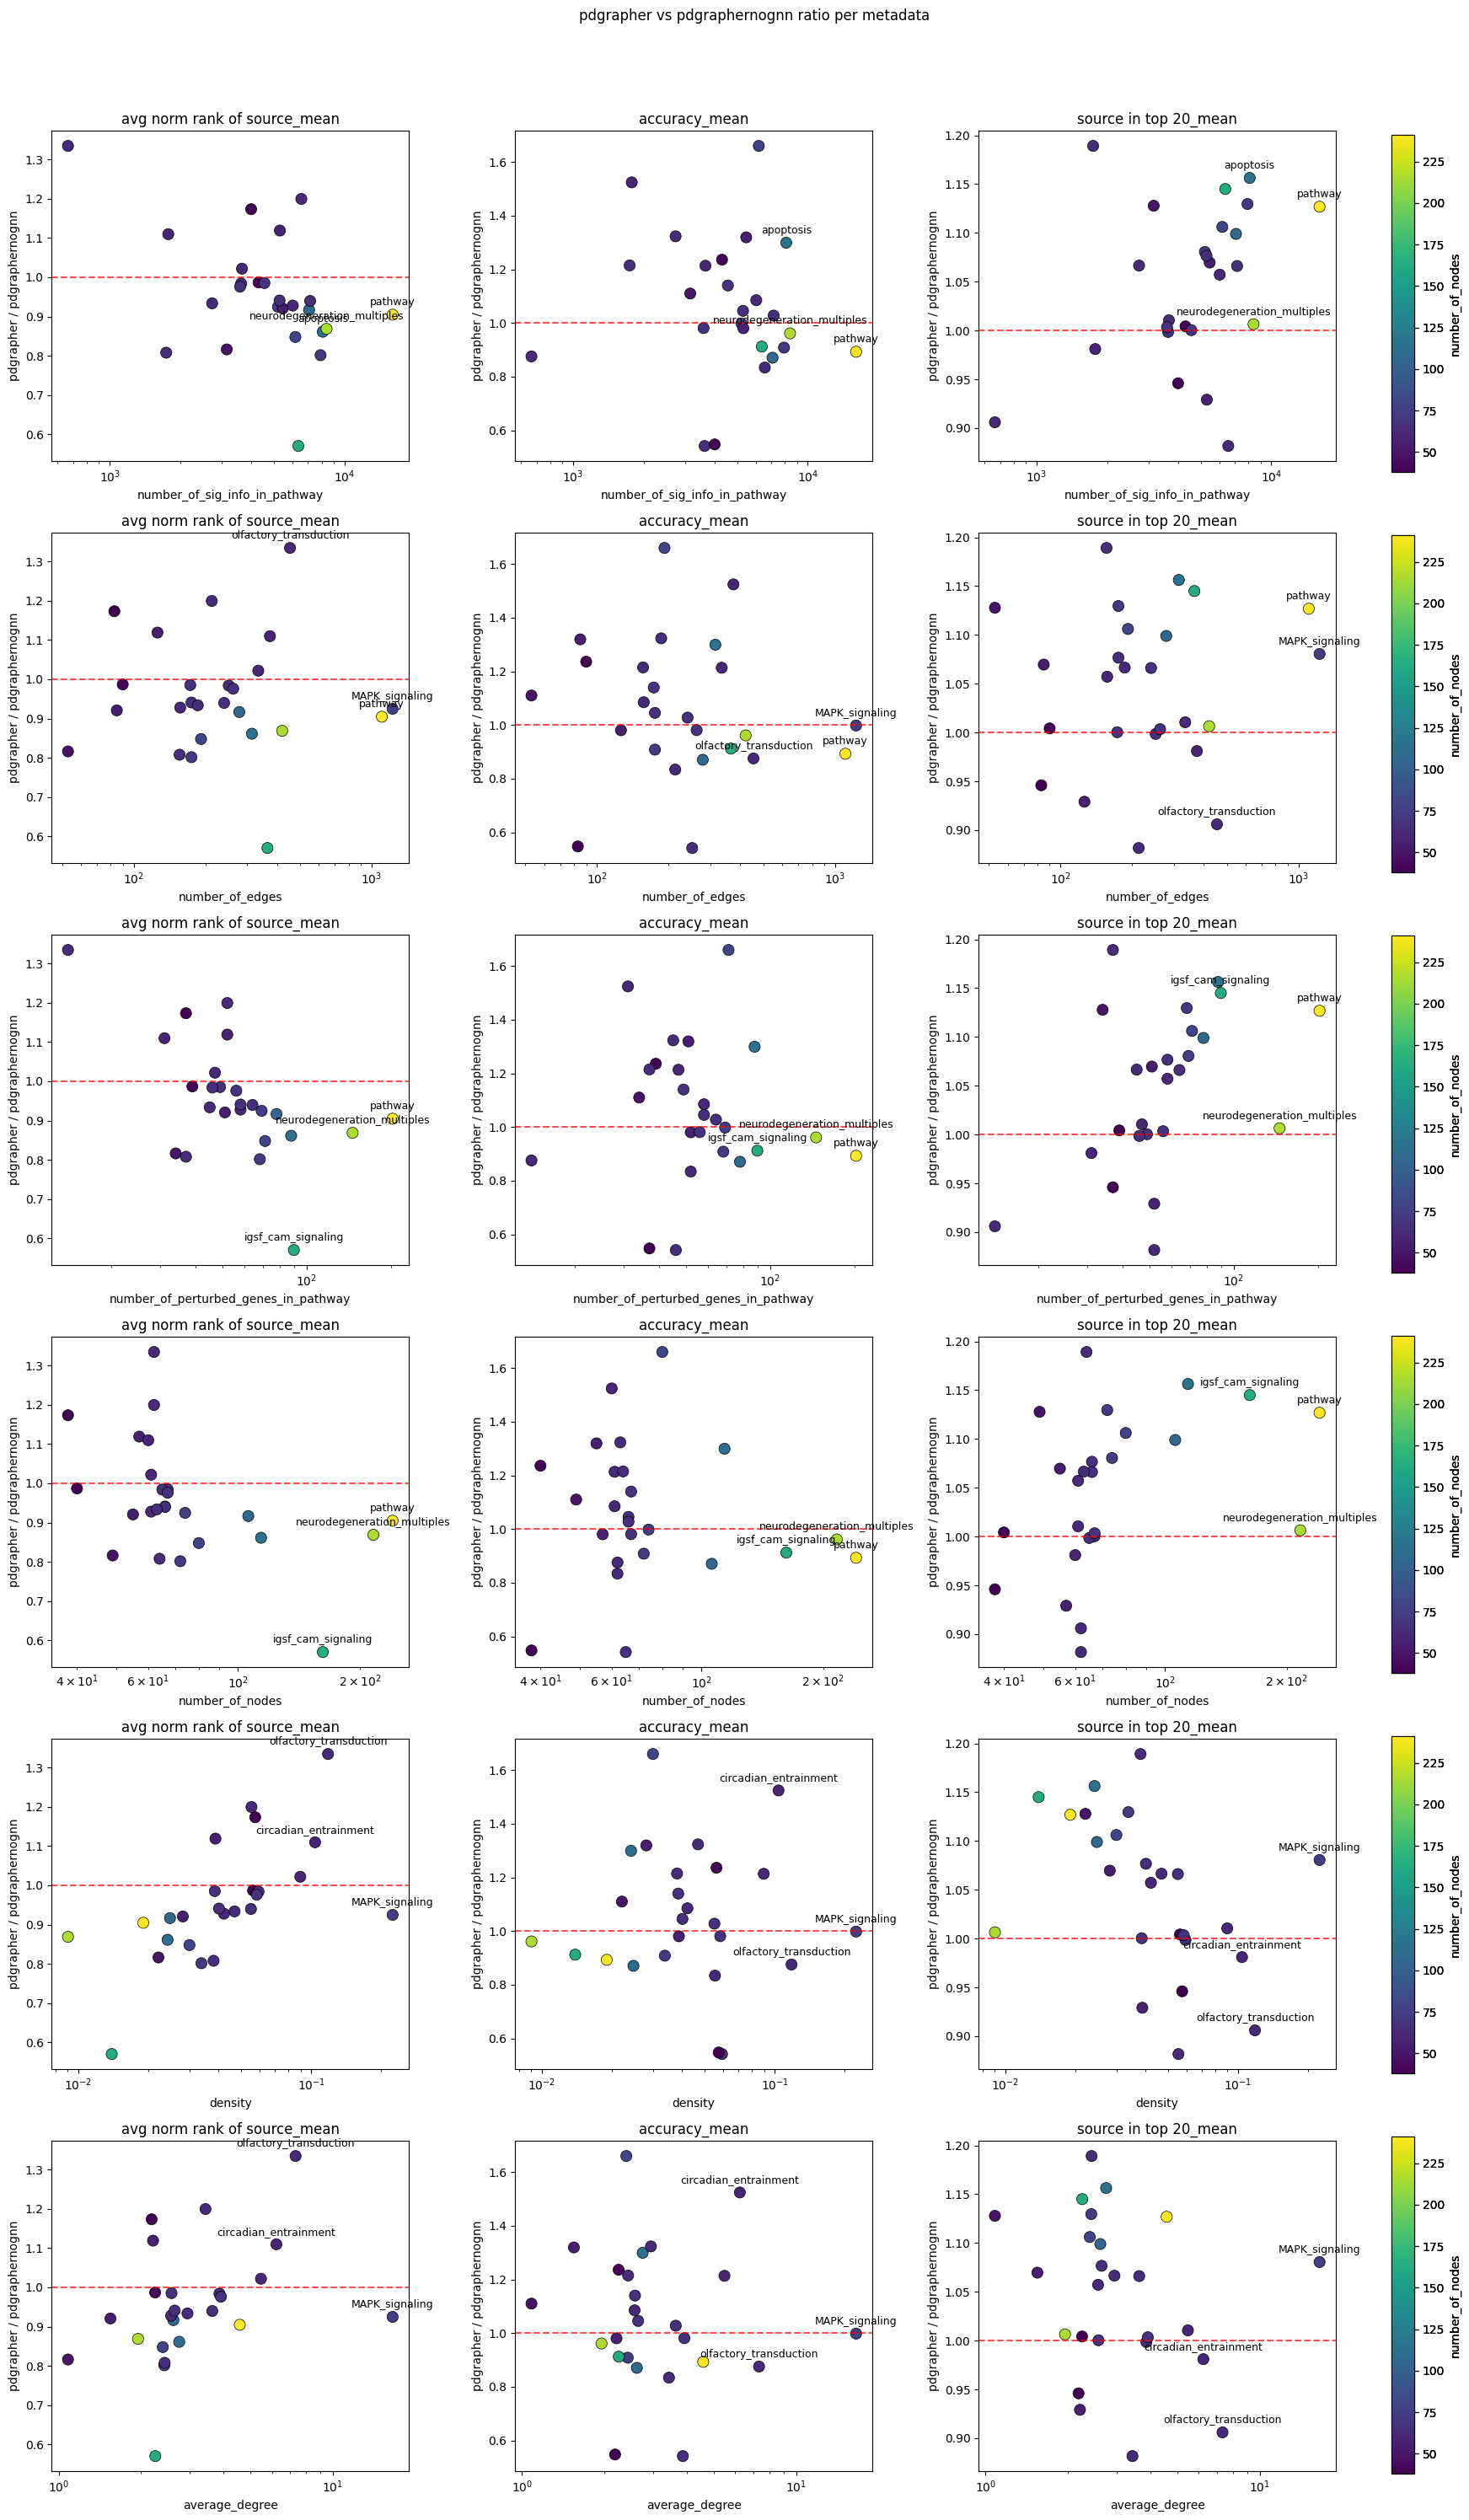

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm

metadata_metrics = ["average_degree", "density", "number_of_nodes", "number_of_perturbed_genes_in_pathway", "number_of_edges", "number_of_sig_info_in_pathway"]

# ============================================================
# Configurable options
# ============================================================
only_perturbed_nodes = False    # True: use number_of_perturbed_genes, False: use total nodes
color_by_ratio = False          # True: color = sig_info / nodes, False: color = nodes or perturbed genes

# ============================================================
# Prepare figure grid
# ============================================================
num_meta = len(metadata_metrics)
num_perf = len(metrics)

fig, axs = plt.subplots(num_meta, num_perf, figsize=(6 * num_perf, 5 * num_meta))

# Ensure axs is always 2D for consistent indexing
if num_meta == 1:
    axs = np.array([axs])
if num_perf == 1:
    axs = axs.reshape(num_meta, 1)

# ============================================================
# Loop over metadata metrics (rows) and performance metrics (columns)
# ============================================================
for row_idx, meta_metric in enumerate(metadata_metrics):
    # Collect all metadata values for normalization / log scaling
    meta_values_all = []
    for perf_metric in metrics:
        for exp in data[perf_metric]["experiment"]:
            # Skip "combined" if color_by_ratio is False
            if not color_by_ratio and "combined" in exp.lower():
                continue
            meta_val = kegg_all_metrics.get(normalize_name(exp), {}).get(meta_metric, np.nan)
            if not np.isnan(meta_val):
                meta_values_all.append(meta_val)

    meta_values_all = np.array(meta_values_all, dtype=float)
    if len(meta_values_all) == 0:
        print(f"No data for metadata metric '{meta_metric}', skipping row.")
        continue

    vmin, vmax = np.min(meta_values_all), np.max(meta_values_all)
    if vmin > 0 and vmax / vmin >= 100:
        norm = LogNorm(vmin=vmin, vmax=vmax)
        cbar_label = f"{meta_metric} (log scale)"
    else:
        norm = Normalize(vmin=vmin, vmax=vmax)
        cbar_label = meta_metric

    mappable = None

    for col_idx, perf_metric in enumerate(metrics):
        ax = axs[num_meta - 1 - row_idx, col_idx]  # Correct row order (top → bottom)

        exps = data[perf_metric]["experiment"]
        pdgrapher_vals = np.array(data[perf_metric]["pdgrapher"], dtype=float)
        pdgraphernognn_vals = np.array(data[perf_metric]["pdgraphernognn"], dtype=float)

        # --- Filter and compute metadata, color, and ratio values ---
        meta_vals, color_vals, ratio_vals_filtered, exps_filtered = [], [], [], []

        for exp_idx, exp in enumerate(exps):
            if not color_by_ratio and "combined" in exp.lower():
                continue

            exp_name = normalize_name(exp)
            exp_metrics = kegg_all_metrics.get(exp_name, {})

            # Metadata value for x-axis
            meta_val = exp_metrics.get(meta_metric, np.nan)
            meta_vals.append(meta_val)

            # Compute color
            if only_perturbed_nodes:
                num_nodes = exp_metrics.get("number_of_perturbed_genes_in_pathway", np.nan)
            else:
                num_nodes = exp_metrics.get("number_of_nodes", np.nan)

            if color_by_ratio:
                sig_info = exp_metrics.get("number_of_sig_info_in_pathway", np.nan)
                color_val = sig_info / num_nodes if num_nodes else np.nan
            else:
                color_val = num_nodes

            color_vals.append(color_val)
            ratio_vals_filtered.append(pdgrapher_vals[exp_idx] / pdgraphernognn_vals[exp_idx])
            exps_filtered.append(exp)

        meta_vals = np.array(meta_vals, dtype=float)
        color_vals = np.array(color_vals, dtype=float)
        ratio_vals_filtered = np.array(ratio_vals_filtered, dtype=float)

        # --- Scatter plot ---
        scatter = ax.scatter(
            meta_vals,
            ratio_vals_filtered,
            c=color_vals,
            cmap="viridis",
            norm=Normalize(vmin=np.nanmin(color_vals), vmax=np.nanmax(color_vals)),
            s=90,
            edgecolors="black",
            linewidths=0.5,
            zorder=2,
        )
        mappable = scatter

        # --- Logarithmic x-axis ---
        ax.set_xscale("log")

        # --- Annotate top 10% outliers ---
        threshold = np.percentile(meta_vals, 90)
        for j, val in enumerate(meta_vals):
            if val >= threshold:
                ax.annotate(
                    exps_filtered[j],
                    (meta_vals[j], ratio_vals_filtered[j]),
                    textcoords="offset points",
                    xytext=(0, 8),
                    ha="center",
                    fontsize=9,
                )
            if exps_filtered[j].lower().find("combined") != -1:
                ax.annotate(
                    exps_filtered[j],
                    (meta_vals[j], ratio_vals_filtered[j]),
                    textcoords="offset points",
                    xytext=(0, 8),
                    ha="center",
                    fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7),
                )

        # --- Labels and reference line ---
        ax.set_xlabel(meta_metric)
        ax.set_ylabel("pdgrapher / pdgraphernognn")
        ax.set_title(perf_metric)
        ax.axhline(1.0, color="r", linestyle="--", alpha=0.7)

        # --- Colorbar per row ---
        cax = fig.add_axes([
            0.92,
            (num_meta - 1 - row_idx) * (0.95 / num_meta) + 0.02,
            0.015,
            0.8 / num_meta
        ])
        cbar = fig.colorbar(mappable, cax=cax)
        if color_by_ratio:
            if only_perturbed_nodes:
                cbar.set_label("sig_info / perturbed genes")
            else:
                cbar.set_label("sig_info / nodes")
        else:
            if only_perturbed_nodes:
                cbar.set_label("number_of_perturbed_genes")
            else:
                cbar.set_label("number_of_nodes")

# --- Figure title and layout ---
filter_info = ""
if metadata_ranges:
    filter_parts = [f"{k}: [{v[0]}, {v[1]}]" for k, v in metadata_ranges.items()]
    filter_info = f" (Filtered: {', '.join(filter_parts)})"

fig.suptitle(f"pdgrapher vs pdgraphernognn ratio per metadata{filter_info}", fontsize=12, y=0.995)
plt.tight_layout(rect=[0, 0, 0.92, 0.97])

# --- Save figure ---
output_filename = "comparison_ratio_scatter_grid.png"
plt.savefig(output_filename)
print(f"Saved plot to {output_filename}")
plt.close(fig)

fig